In [1]:
from matplotlib import pyplot as plt

from py_eddy_tracker.dataset.grid import RegularGridDataset

import cartopy.crs as ccrs

from py_eddy_tracker.observations.observation import EddiesObservations

from glob import glob
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy

import xarray as xr

import pandas as pd
from datetime import timedelta


# Params.

In [2]:
nyear = 2024

nmonth = 4

# Functions

In [3]:
def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.05, 0.01, 0.9]))

In [4]:
def get_file_start_time(f):
    """Extract start datetime from SWOT filename."""
    basename = os.path.basename(f)
    # e.g. ...20230811T021853_20230811T031019...
    time_str = basename.split('_')[-3]  # '20230811T021853'
    return pd.to_datetime(time_str, format='%Y%m%dT%H%M%S')


In [5]:
def start_axes_map_gridspec(fig, position, title, lon_min_ax=-6., lon_max_ax=9., lat_min_ax=35., lat_max_ax=45., right_gl=False, top_gl=False):
    """
    Create a map axis at the specified gridspec position with consistent styling.
    """
    ax = fig.add_subplot(position, projection=ccrs.PlateCarree())
    ax.set_xlim(lon_min_ax, lon_max_ax)
    ax.set_ylim(lat_min_ax, lat_max_ax)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold", fontsize=11)
    ax.add_feature(cartopy.feature.LAND, facecolor=cartopy.feature.COLORS['land'], zorder=2) #'k') #cartopy.feature.COLORS['land'])
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    if right_gl:
        gl.left_labels = False
    if top_gl:
        gl.bottom_labels = False

    return ax


# Loading data:

In [6]:
from pathlib import Path

# Get the user's home directory
homedir = Path.home()
# print(f"Home directory: {homedir}")

In [7]:
indir_miost = str(homedir) + "/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/"
indir_miost_s = indir_miost + 'subset/'


In [8]:
data_paths = sorted(glob(indir_miost_s + "dt_global_allsat_phy_l4_" + str(nyear) + str(nmonth).zfill(2) + "*_sub.nc"))

In [9]:
len(data_paths)

30

In [10]:
indir_eddies = "data/eddy-tracker_outputs/"

In [11]:
xr.open_dataset(data_paths[0])

<xarray.Dataset>
Dimensions:           (time: 1, latitude: 88, longitude: 120, bounds: 2)
Coordinates:
  * longitude         (longitude) float32 -5.938 -5.812 -5.688 ... 8.812 8.938
  * latitude          (latitude) float32 34.06 34.19 34.31 ... 44.69 44.81 44.94
  * time              (time) datetime64[ns] 2024-04-01
    longitude_bounds  (longitude, bounds) float64 ...
    latitude_bounds   (latitude, bounds) float64 ...
Dimensions without coordinates: bounds
Data variables:
    sla               (time, latitude, longitude) float64 ...
    ugosa             (time, latitude, longitude) float64 ...
    vgosa             (time, latitude, longitude) float64 ...
    adt               (time, latitude, longitude) float64 ...
    ugos              (time, latitude, longitude) float64 ...
    vgos              (time, latitude, longitude) float64 ...
Attributes: (12/46)
    description:                      Miost analysis 
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    title:                           DT merged all satellites Global Ocean Gr...
    time_coverage_start:             2024-04-01T12:00:00Z
    time_coverage_end:               2024-04-01T12:00:00Z
    doi:                             10.24400/527896/a01-2025.001

In [12]:
ds_miost = xr.open_dataset(data_paths[0])


In [13]:
swot_files = sorted(glob(str(homedir) + "/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/" + "*" + str(nyear) + str(nmonth).zfill(2) + "*.nc"))

## Plotting ADT with contours ontop:

In [14]:
data_paths[10]

'/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240411_sub.nc'

In [15]:
data_path = data_paths[10]

# Day 20/04/2024:

## Pre-plot for SWOT data oon 20/04/2024:

We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240420_sub.nc


['/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_014_070_20240419T222941_20240419T232108_v2.0.1.nc', '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_014_085_20240420T112124_20240420T121250_v2.0.1.nc']


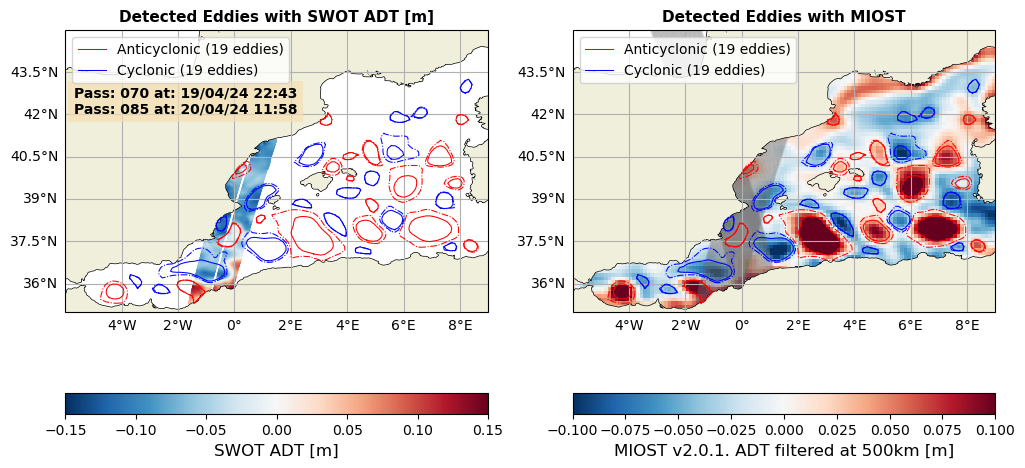

In [16]:
data_path = data_paths[19]  # to select day 20/04

fig = plt.figure(figsize=(12, 7))

gs = gridspec.GridSpec(1, 2) 

# MIOST data
ds_miost = xr.open_dataset(data_path)

# SWOT files
ref_time = pd.Timestamp(ds_miost.time.values[0])
delta = timedelta(hours=12)

swot_matching_files = [
    f for f in swot_files
    if abs(get_file_start_time(f) - ref_time) <= delta
]

print(swot_matching_files)

# date for eddy id:
date = pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')

g = RegularGridDataset(data_path, "longitude", "latitude")
g.add_uv("adt")
g.bessel_high_filter("adt", 500)

a_name = indir_eddies + 'a_MIOST_v2.0.1_' + date + '.nc'
c_name = indir_eddies + 'c_MIOST_v2.0.1_' + date + '.nc'

a = EddiesObservations.load_file(a_name)
c = EddiesObservations.load_file(c_name)

########
# Subplot 1
ax = start_axes_map_gridspec(fig, gs[0], "Detected Eddies with SWOT ADT [m]") 

swot_pass_times = []
for swot_file in swot_matching_files:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r') 

    swot_pass_times.append(pd.to_datetime(ds_sw.time.mean().values).strftime('%d/%m/%y %H:%M'))

cbar = plt.colorbar(m, orientation='horizontal')
cbar.set_label('SWOT ADT [m]', fontsize=12)

# contours
a.display(
    ax, color="r", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
)
c.display(
    ax, color="b", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
)
ax.legend(loc=2)

swot_info = '\n'.join(
    f"Pass: {ff.split('/')[-1].split('_')[7]} at: {tt}"
    for ff, tt in zip(swot_matching_files, swot_pass_times)
)
if not swot_info:
    swot_info = 'No SWOT pass'

ax.text(0.02, 0.8, swot_info, transform=ax.transAxes,
    fontsize=10, weight='bold', va='top', ha='left',
    bbox=dict(facecolor='wheat', alpha=0.7, edgecolor='none'))

########################
# Subplot 2
ax = start_axes_map_gridspec(fig, gs[1], "Detected Eddies with MIOST") 
m = g.display(ax, "adt", vmin=-0.1, vmax=0.1, cmap="RdBu_r")

cbar = plt.colorbar(m, orientation='horizontal')
cbar.set_label('MIOST v2.0.1. ADT filtered at 500km [m]', fontsize=12)

a.display(
    ax, color="r", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
)
c.display(
    ax, color="b", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
)
ax.legend(loc=2)
update_axes(ax)

for swot_file in swot_matching_files:
    ds_sw = xr.open_dataset(swot_file)
    ax.scatter(ds_sw.longitude, ds_sw.latitude, s=0.1, c='grey', alpha=0.1, transform=ccrs.PlateCarree()) 

##############

plt.show()    


# Now plotting day +/- 10 days:

In [17]:
swot_matching_files_20 = swot_matching_files # from plot cell above
swot_matching_files_20

['/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_014_070_20240419T222941_20240419T232108_v2.0.1.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_014_085_20240420T112124_20240420T121250_v2.0.1.nc']

In [18]:
swot_matching_files_1dm = [swot_files[19], swot_files[20]]
swot_matching_files_1dp = [swot_files[23], swot_files[24]]

In [19]:
swot_matching_files_2dm = [swot_files[17], swot_files[18]]
swot_matching_files_2dp = [swot_files[25]]

In [20]:
swot_matching_files_3dm = [swot_files[15], swot_files[16]]
swot_matching_files_4dm = [swot_files[14]]

In [21]:
swot_matching_files_6dp = [swot_files[26]]
swot_matching_files_7dp = [swot_files[27], swot_files[28]]

In [22]:
swot_files[9:15]

['/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_013_363_20240409T125834_20240409T135001_v2.0.1.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_013_376_20240410T000723_20240410T005849_v2.0.1.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_013_391_20240410T125906_20240410T135032_v2.0.1.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_013_404_20240411T000754_20240411T005921_v2.0.1.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH

In [23]:
swot_matching_files_8dm = [swot_files[13]]
swot_matching_files_8dp = [swot_files[29], swot_files[30]]

In [24]:
swot_matching_files_9dm = [swot_files[11], swot_files[12]]
swot_matching_files_9dp = [swot_files[31], swot_files[32]]

In [25]:
swot_matching_files_10dm = [swot_files[9], swot_files[10]]
swot_matching_files_10dp = [swot_files[33], swot_files[34]]

We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240420_sub.nc


['/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_014_070_20240419T222941_20240419T232108_v2.0.1.nc', '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT_meu/Data/SWOT/ftp_aviso/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/subset/subset_SWOT_L3_LR_SSH_Expert_014_085_20240420T112124_20240420T121250_v2.0.1.nc']


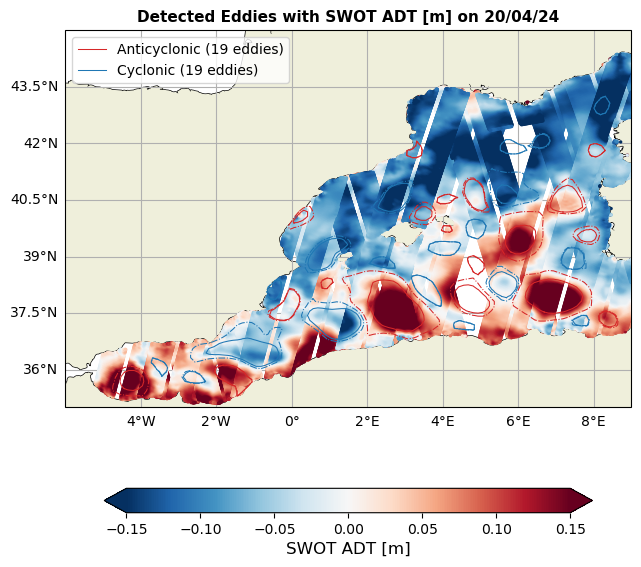

In [26]:
data_path = data_paths[19]  
fig = plt.figure(figsize=(9, 7))

gs = gridspec.GridSpec(1, 1) 

# MIOST data
ds_miost = xr.open_dataset(data_path)

# SWOT files
ref_time = pd.Timestamp(ds_miost.time.values[0])
delta = timedelta(hours=12)

swot_matching_files = [
    f for f in swot_files
    if abs(get_file_start_time(f) - ref_time) <= delta
]

print(swot_matching_files)

# date for eddy id:
date = pd.Timestamp(ds_miost.time.values[0]).strftime('%Y%m%d')

g = RegularGridDataset(data_path, "longitude", "latitude")
g.add_uv("adt")
g.bessel_high_filter("adt", 500)

a_name = indir_eddies + 'a_MIOST_v2.0.1_' + date + '.nc'
c_name = indir_eddies + 'c_MIOST_v2.0.1_' + date + '.nc'
a = EddiesObservations.load_file(a_name)
c = EddiesObservations.load_file(c_name)

########
# Subplot 1
ax = start_axes_map_gridspec(fig, gs[0], "Detected Eddies with SWOT ADT [m] on 20/04/24") 

swot_pass_times = []

####################
# Days +/-10days
for swot_file in swot_matching_files_10dm:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=11) #  ,

for swot_file in swot_matching_files_10dp:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=12) #  ,

####################
# Days +/-9
for swot_file in swot_matching_files_9dm:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=13) 

for swot_file in swot_matching_files_9dp:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=14) 

####################
# Days +/-8
for swot_file in swot_matching_files_8dm:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=15) 

for swot_file in swot_matching_files_8dp:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=16) 

####################
# Days +6 and +7
for swot_file in swot_matching_files_7dp:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=17) 

for swot_file in swot_matching_files_6dp:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=18) 


####################
# Days -3 and -4
for swot_file in swot_matching_files_4dm:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=19) 

for swot_file in swot_matching_files_3dm:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=20) 

####################
# Days +/-2
for swot_file in swot_matching_files_1dm:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=21) 

for swot_file in swot_matching_files_1dp:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=22) 

####################
# Days +/-1
for swot_file in swot_matching_files_1dm:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=23) 

for swot_file in swot_matching_files_1dp:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=24) 
####################
# Day 20
for swot_file in swot_matching_files:
    ds_sw = xr.open_dataset(swot_file)

    # Masking NATL
    ds_sw = ds_sw.where(~((ds_sw.longitude < 0.) & (ds_sw.latitude > 43.))) 
    
    m = ax.scatter(ds_sw.longitude, ds_sw.latitude, c=ds_sw.ssha_filtered+ds_sw.mdt, s=2
                    , vmin = -0.15, vmax = 0.15 
                    , transform=ccrs.PlateCarree(), cmap='RdBu_r', zorder=25) 

    swot_pass_times.append(pd.to_datetime(ds_sw.time.mean().values).strftime('%d/%m/%y %H:%M'))

cbar = plt.colorbar(m, orientation='horizontal', extend='both', shrink=.7)
cbar.set_label('SWOT ADT [m]', fontsize=12)

# contours
a.display(
    ax, color="C3", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), zorder=50
)
c.display(
    ax, color="C0", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), zorder=51
)
ax.legend(loc=2)

swot_info = '\n'.join(
    f"Pass: {ff.split('/')[-1].split('_')[7]} at: {tt}"
    for ff, tt in zip(swot_matching_files, swot_pass_times)
)
if not swot_info:
    swot_info = 'No SWOT pass'

#####
plt.savefig("figures/figA1.png", dpi=300, bbox_inches="tight")

plt.show()    


# Code references

https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_eddy_detection.html